# Análisis de Evolución de Cobertura del Suelo (2 Suelo (2009-2024)

Municipios: Cachipay, Anolaima, Zipacón, Facatativa, Mosquera, Madrid

## 1. Objetivo del Análisis
Evaluar la evolución temporal de la proporción de diferentes coberturas del suelo (natural, antrópico, cuerpos de agua y áreas agropecuarias) en seis municipios de Cundinamarca para comprender cómo la expansión de áreas agropecuarias ha afectado a la vegetación natural.

## 2. Fuente de Datos
- Archivo: `data/Statistics-for-Website-MB-Cobertura-col3.xlsx`
- Hoja: `COBERTURA_MUNICIPIO`
- Columnas: municipio, class_level_0, class_level_1, class_level_2, y columnas de años 1985-2024 (hectáreas).

## 3. Municipios de Interesse y Comparación
- Grupo de interés (presumiblemente más rurales): Cachipay, Anolaima, Zipacón
- Grupo de comparación (presumiblemente más urbanizados/periurbanos): Facatativa, Mosquera, Madrid

## 4. Metodología
### 4.1 Preparación de los Datos
1. Cargar la hoja `COBERTURA_MUNICIPIO`.
2. Filtrar los seis municipios.
3. Para cada municipio y cada año (2009‑2024):
   - Área total = suma de todas las clases.
   - Área natural = suma donde class_level_0 == "Natural".
   - Área antrópica = suma donde class_level_0 == "Antrópico".
   - Área de cuerpo de agua = suma donde class_level_1 == "5. Cuerpo de agua".
   - Área agropecuaria = suma donde class_level_1 == "3. Área agropecuaria".
4. Calcular proporciones (área de cada categoría / área total).
5. Calcular razones:
   - R1 = Área Natural / Área de Agua
   - R2 = Área Antropófica / Área de Agua
   - R3 = Área Natural / Área Agropecuaria
   - R4 = Área Antropófica / Área Agropecuaria (opcional)
6. Organizar en formato tidy: [municipio, año, R1, R2, R3, R4].

### 4.2 Análisis Temporal
- **Anual (2009‑2024)**: gráficos de líneas para cada razón por municipio.
- **Cada 5 años**: años 2009, 2014, 2019, 2024 o promedios móviles de 5 años.

### 4.3 Comparación entre Grupos
- Agrupar municipios en "Rurales" y "Urbanos/Periurbanos".
- Calcular media y desviación típica por grupo y año.
- Pruebas t‑test independientes.
- Visualización con boxplots o líneas con bandas de error.

### 4.4 Análisis Adicional (Recomendado)
- Descomposición por subclases (class_level_2).
- Análisis de cambio neto (hectáreas y % del área total inicial).
- Correlación entre razones.
- Análisis de residuos de tendencias lineales.

## 5. Implementación

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

warnings.filterwarnings('ignore')
%matplotlib inline


In [4]:

# Load the Excel file
excel_file = '../data/Statistics-for-Website-MB-Cobertura-col3.xlsx'
df = pd.read_excel(excel_file, sheet_name='COBERTURA_MUNICIPIO')
print('Shape of data:', df.shape)
print('Columns:', df.columns.tolist())
print('First few rows:')
display(df.head())


Shape of data: (10226, 46)
Columns: ['municipio', 'departamento', 'pais', 'class_level_0', 'class_level_1', 'class_level_2', 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
First few rows:


,municipio,departamento,pais,class_level_0,class_level_1,class_level_2,1985,1986,1987,1988,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Entidad Territorial Indigena Consejo Indigena ...,Amazonas,Colombia,Antrópico,3. Área agropecuaria,3.4. Mosaico de agricultura o pasto,3283.803378,3674.305718,3539.470185,3676.351197,...,4263.830813,4577.495181,4754.504396,4609.528692,4464.093669,4241.325706,4135.035991,4177.885907,4820.203366,4985.516990
1,Entidad Territorial Indigena Consejo Indigena ...,Amazonas,Colombia,Antrópico,4. Área sin vegetación,4.2. Infraestructura urbana,7.148547,7.148547,7.774045,7.774045,...,12.778026,12.778026,12.778026,12.778026,12.778026,12.778026,12.778026,12.778026,12.778026,12.778026
2,Entidad Territorial Indigena Consejo Indigena ...,Amazonas,Colombia,Antrópico,4. Área sin vegetación,4.5. Otra área sin vegetación,13.310616,15.456024,14.652717,9.290065,...,3.305720,7.059316,7.326766,8.757271,31.899984,6.345242,10.277374,10.455808,14.834556,22.609312
3,Entidad Territorial Indigena Consejo Indigena ...,Amazonas,Colombia,Natural,1. Formacion Boscosa,1.1. Bosque,408653.165475,407518.445567,414301.458358,416711.661663,...,412696.551889,412274.847324,411513.260208,413470.925139,413576.756788,412926.007004,410836.284117,411465.153042,409410.476028,409236.720659
4,Entidad Territorial Indigena Consejo Indigena ...,Amazonas,Colombia,Natural,1. Formacion Boscosa,1.3. Bosque inundable,138862.384702,137365.538097,132845.574225,131175.551151,...,129073.192212,129285.519036,129180.512597,127583.738009,129949.953926,132152.931425,132649.858313,133147.287564,135082.442304,134862.476542


In [3]:

targets = ['Cachipay', 'Anolaima', 'Zipacón', 'Facatativá', 'Mosquera', 'Madrid']
print('Searching for target municipalities:')
for t in targets:
    matches = df[df['municipio'].str.contains(t, case=False, na=False)]
    if len(matches) > 0:
        print(f"{t}: Found {len(matches)} rows")
        # Show exact matches
        exact = df[df['municipio'] == t]
        if len(exact) > 0:
            print(f"  Exact match: {exact['municipio'].iloc[0]}")
        else:
            print(f"  Partial matches: {matches['municipio'].unique()}")
    else:
        print(f"{t}: Not found")


Searching for target municipalities:
Cachipay: Found 6 rows
  Exact match: Cachipay
Anolaima: Found 6 rows
  Exact match: Anolaima
Zipacón: Found 8 rows
  Exact match: Zipacón
Facatativá: Found 8 rows
  Exact match: Facatativá
Mosquera: Found 18 rows
  Exact match: Mosquera
Madrid: Found 9 rows
  Exact match: Madrid


In [4]:

# Based on inspection, the exact names are:
municipios_of_interest = ['Cachipay', 'Anolaima', 'Zipacón']  # Note: Zipacón with accent
municipios_comparacion = ['Facatativá', 'Mosquera', 'Madrid']  # Facatativá with accent
all_municipios = municipios_of_interest + municipios_comparacion
print('Municipios de interés:', municipios_of_interest)
print('Municipios de comparación:', municipios_comparacion)


Municipios de interés: ['Cachipay', 'Anolaima', 'Zipacón']
Municipios de comparación: ['Facatativá', 'Mosquera', 'Madrid']


In [5]:

# Filter data for the selected municipalities
df_filtered = df[df['municipio'].isin(all_municipios)].copy()
print(f'Filtered data shape: {df_filtered.shape}')
print('Municipios encontrados:', df_filtered['municipio'].unique())


Filtered data shape: (55, 46)
Municipios encontrados: ['Anolaima' 'Cachipay' 'Facatativá' 'Madrid' 'Mosquera' 'Zipacón']


In [6]:

# Years of interest
years = list(range(2009, 2025))  # 2009 to 2024 inclusive
print('Years:', years)
# Ensure year columns exist
available_cols = [str(y) for y in years if str(y) in df_filtered.columns]
print('Available year columns:', len(available_cols))


Years: [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Available year columns: 0


In [7]:

def compute_areas_for_municipio(df_mun, years):
    """Compute areas for each year for a given municipality dataframe."""
    # Ensure year columns are numeric
    year_cols = years #[str(y) for y in years]
    # Convert to numeric, coercing errors
    for col in year_cols:
        df_mun[col] = pd.to_numeric(df_mun[col], errors='coerce')
    # Compute totals
    areas = {}
    for year in year_cols:
        total_area = df_mun[year].sum()
        natural_area = df_mun.loc[df_mun['class_level_0'] == 'Natural', year].sum()
        anthropic_area = df_mun.loc[df_mun['class_level_0'] == 'Antrópico', year].sum()
        water_area = df_mun.loc[df_mun['class_level_1'] == '5. Cuerpo de agua', year].sum()
        agro_area = df_mun.loc[df_mun['class_level_1'] == '3. Área  agropecuaria', year].sum()
        # Avoid division by zero
        if total_area == 0 or np.isnan(total_area):
            total_area = np.nan
        if water_area == 0 or np.isnan(water_area):
            water_area = np.nan
        if agro_area == 0 or np.isnan(agro_area):
            agro_area = np.nan
        areas[year] = {
            'total_area': total_area,
            'natural_area': natural_area,
            'anthropic_area': anthropic_area,
            'water_area': water_area,
            'agro_area': agro_area,
            'prop_natural': natural_area / total_area if total_area not in [0, np.nan] else np.nan,
            'prop_anthropic': anthropic_area / total_area if total_area not in [0, np.nan] else np.nan,
            'prop_water': water_area / total_area if total_area not in [0, np.nan] else np.nan,
            'prop_agro': agro_area / total_area if total_area not in [0, np.nan] else np.nan,
            'R1_natural_water': natural_area / water_area if water_area not in [0, np.nan] else np.nan,
            'R2_anthropic_water': anthropic_area / water_area if water_area not in [0, np.nan] else np.nan,
            'R3_natural_agro': natural_area / agro_area if agro_area not in [0, np.nan] else np.nan,
            'R4_anthropic_agro': anthropic_area / agro_area if agro_area not in [0, np.nan] else np.nan,
        }
    return areas


In [8]:

results = []
for mun in all_municipios:
    df_mun = df_filtered[df_filtered['municipio'] == mun].copy()
    if df_mun.empty:
        print(f"Warning: No data for {mun}")
        continue
    areas_dict = compute_areas_for_municipio(df_mun, years)
    for year, vals in areas_dict.items():
        vals['municipio'] = mun
        vals['year'] = int(year)
        results.append(vals)
df_results = pd.DataFrame(results)
print('Results shape:', df_results.shape)
display(df_results.head())


Results shape: (96, 15)


,total_area,natural_area,anthropic_area,water_area,agro_area,prop_natural,prop_anthropic,prop_water,prop_agro,R1_natural_water,R2_anthropic_water,R3_natural_agro,R4_anthropic_agro,municipio,year
0,5389.244479,1709.340034,3679.904444,8.999271,3631.522627,0.317176,0.682824,0.001670,0.673846,189.942062,408.911407,0.470695,1.013323,Cachipay,2009
1,5389.244479,1785.076603,3604.167875,3.563995,3567.101958,0.331229,0.668771,0.000661,0.661893,500.863935,1011.271842,0.500428,1.010391,Cachipay,2010
2,5389.244479,1721.635076,3667.609403,2.762105,3632.503651,0.319458,0.680542,0.000513,0.674028,623.305409,1327.831205,0.473953,1.009664,Cachipay,2011
3,5389.244479,1701.141890,3688.102589,2.762105,3648.452816,0.315655,0.684345,0.000513,0.676988,615.886000,1335.250613,0.466264,1.010868,Cachipay,2012
4,5389.244479,1614.711618,3774.532860,3.564014,3730.962540,0.299617,0.700383,0.000661,0.692298,453.059855,1059.067941,0.432787,1.011678,Cachipay,2013


In [9]:
base_year = 2009
base = df_results[df_results["year"] == base_year][["municipio", "prop_natural", "prop_anthropic", "prop_water", "prop_agro"]].rename(
    columns={"prop_natural": "b_natural", "prop_anthropic": "b_anthropic", "prop_water": "b_water", "prop_agro": "b_agro"}
)
df_results = df_results.merge(base, on="municipio", how="left")
df_results["growing_natural"] = (df_results["prop_natural"] - df_results["b_natural"]) / df_results["b_natural"] * 100
df_results["growing_anthropic"] = (df_results["prop_anthropic"] - df_results["b_anthropic"]) / df_results["b_anthropic"] * 100
df_results["growing_water"] = (df_results["prop_water"] - df_results["b_water"]) / df_results["b_water"] * 100
df_results["growing_agro"] = (df_results["prop_agro"] - df_results["b_agro"]) / df_results["b_agro"] * 100
df_results = df_results.drop(columns=["b_natural", "b_anthropic", "b_water", "b_agro"])

In [10]:
print('Results shape:', df_results.shape)
display(df_results.head())

Results shape: (96, 19)


,total_area,natural_area,anthropic_area,water_area,agro_area,prop_natural,prop_anthropic,prop_water,prop_agro,R1_natural_water,R2_anthropic_water,R3_natural_agro,R4_anthropic_agro,municipio,year,growing_natural,growing_anthropic,growing_water,growing_agro
0,5389.244479,1709.340034,3679.904444,8.999271,3631.522627,0.317176,0.682824,0.001670,0.673846,189.942062,408.911407,0.470695,1.013323,Cachipay,2009,0.000000,0.000000,0.000000,0.000000
1,5389.244479,1785.076603,3604.167875,3.563995,3567.101958,0.331229,0.668771,0.000661,0.661893,500.863935,1011.271842,0.500428,1.010391,Cachipay,2010,4.430749,-2.058112,-60.396845,-1.773930
2,5389.244479,1721.635076,3667.609403,2.762105,3632.503651,0.319458,0.680542,0.000513,0.674028,623.305409,1327.831205,0.473953,1.009664,Cachipay,2011,0.719286,-0.334113,-69.307456,0.027014
3,5389.244479,1701.141890,3688.102589,2.762105,3648.452816,0.315655,0.684345,0.000513,0.676988,615.886000,1335.250613,0.466264,1.010868,Cachipay,2012,-0.479609,0.222781,-69.307456,0.466201
4,5389.244479,1614.711618,3774.532860,3.564014,3730.962540,0.299617,0.700383,0.000661,0.692298,453.059855,1059.067941,0.432787,1.011678,Cachipay,2013,-5.535962,2.571491,-60.396636,2.738243


In [11]:

# df_results.to_csv('data/processed/usos_suelo_results.csv', index=False)
# print('Results saved to data/processed/usos_suelo_results.csv')


In [12]:

def plot_ratios_over_time(df_results, ratios=['R1_natural_water', 'R2_anthropic_water', 'R3_natural_agro', 'R4_anthropic_agro'], 
                          title_suffix='', figsize=(14,10)):
    """Plot each ratio over time for each municipality."""
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()
    ratio_names = {
        'R1_natural_water': 'Natural / Agua',
        'R2_anthropic_water': 'Antropófico / Agua',
        'R3_natural_agro': 'Natural / Agropecuario',
        'R4_anthropic_agro': 'Antropófico / Agropecuario'
    }
    for idx, ratio in enumerate(ratios):
        ax = axes[idx]
        for mun in all_municipios:
            df_mun = df_results[df_results['municipio'] == mun].sort_values('year')
            ax.plot(df_mun['year'], df_mun[ratio], marker='o', label=mun)
        ax.set_title(f'{ratio_names.get(ratio, ratio)} {title_suffix}')
        ax.set_xlabel('Año')
        ax.set_ylabel('Ratio')
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


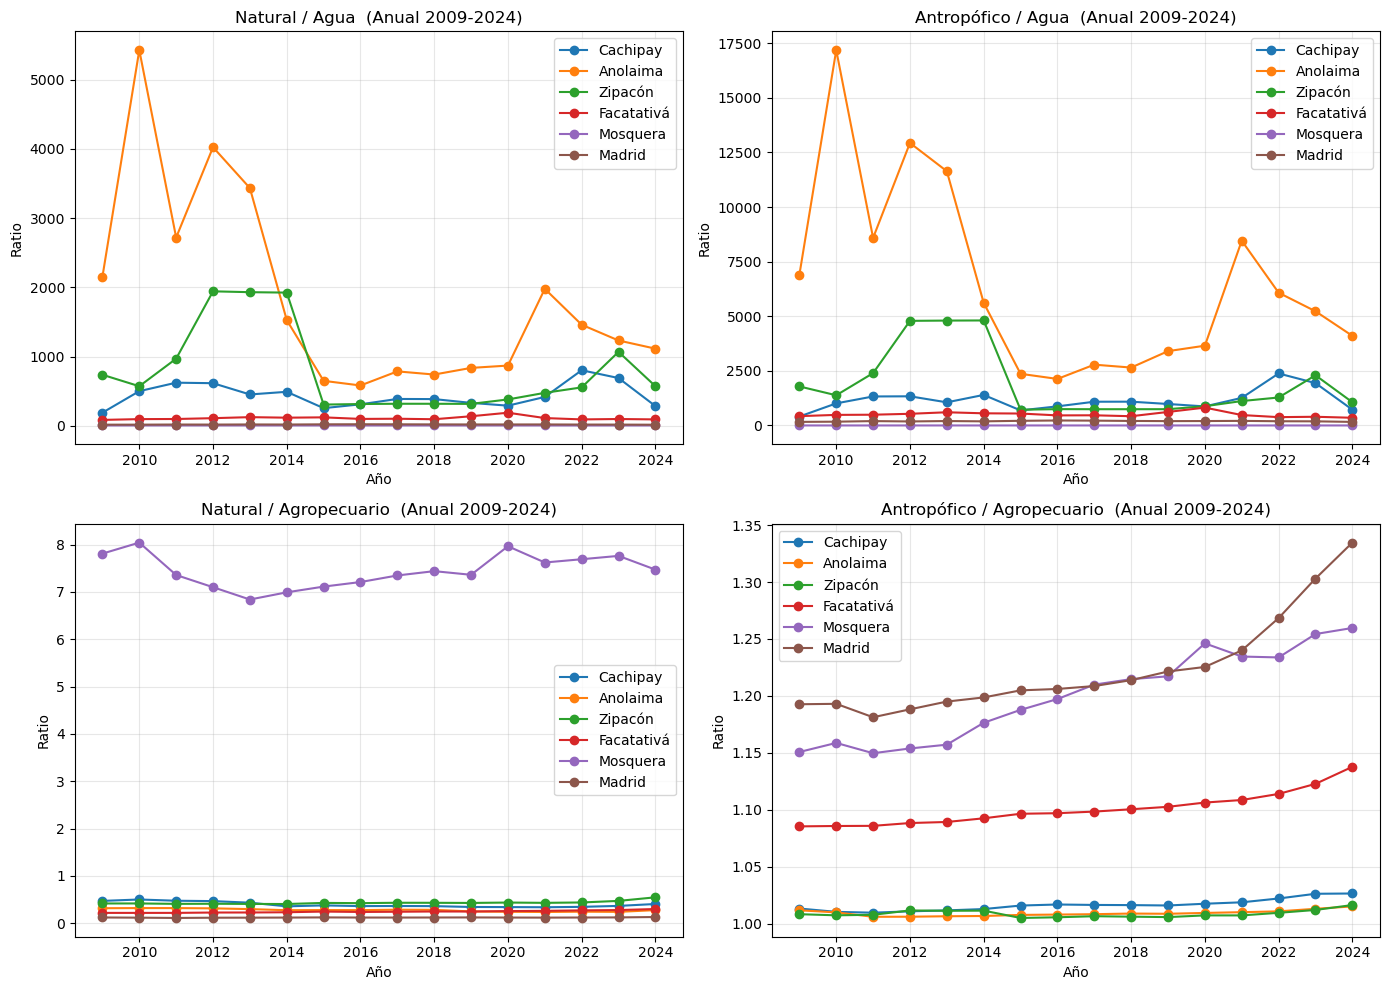

In [13]:

plot_ratios_over_time(df_results, title_suffix=' (Anual 2009-2024)')


In [14]:

# Define 5-year periods: 2009-2013, 2010-2014, ..., 2020-2024
# We'll compute average for each 5-year window
five_year_data = []
start_years = list(range(2009, 2021))  # 2009 to 2020 inclusive (last window 2020-2024)
for start in start_years:
    end = start + 4
    if end > 2024:
        break
    label = f'{start}-{end}'
    for mun in all_municipios:
        df_mun = df_results[(df_results['municipio'] == mun) & 
                            (df_results['year'] >= start) & 
                            (df_results['year'] <= end)]
        if df_mun.empty:
            continue
        # Compute mean for each ratio
        row = {'municipio': mun, 'period': label, 'start_year': start, 'end_year': end}
        for ratio in ['R1_natural_water', 'R2_anthropic_water', 'R3_natural_agro', 'R4_anthropic_agro']:
            row[ratio] = df_mun[ratio].mean()
        five_year_data.append(row)
df_five = pd.DataFrame(five_year_data)
print('5-year periods shape:', df_five.shape)
display(df_five.head())


5-year periods shape: (72, 8)


,municipio,period,start_year,end_year,R1_natural_water,R2_anthropic_water,R3_natural_agro,R4_anthropic_agro
0,Cachipay,2009-2013,2009,2013,476.611452,1028.466601,0.468825,1.011185
1,Anolaima,2009-2013,2009,2013,3552.654901,11445.944131,0.312865,1.008083
2,Zipacón,2009-2013,2009,2013,1230.848030,3031.142400,0.411709,1.009301
3,Facatativá,2009-2013,2009,2013,103.356454,508.502846,0.220577,1.086974
4,Mosquera,2009-2013,2009,2013,5.527738,0.861681,7.427968,1.154053


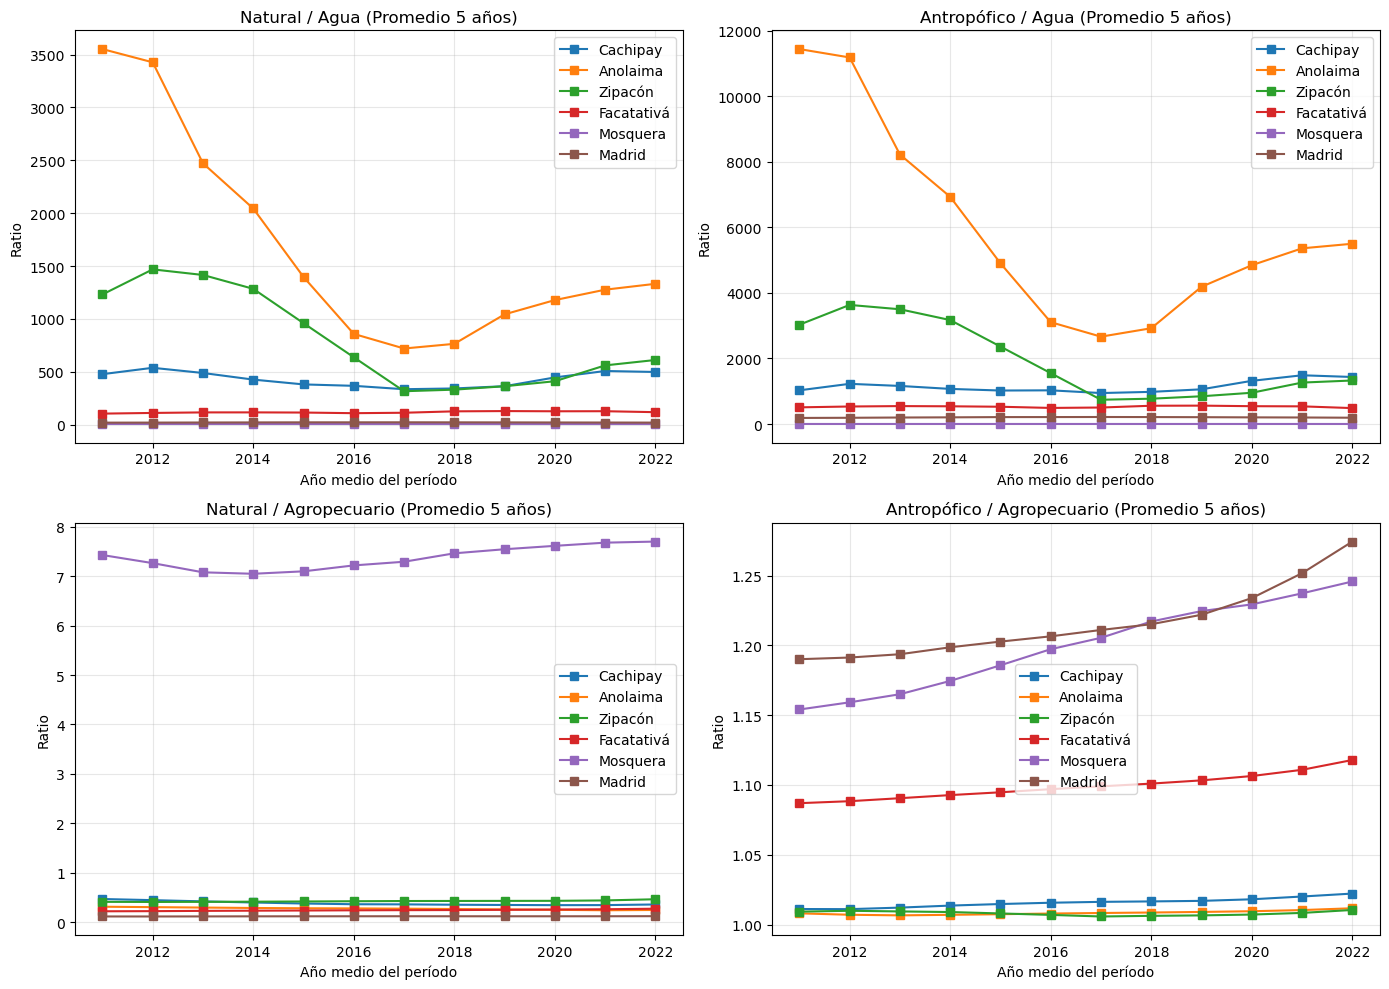

In [15]:

def plot_5year(df_five, ratios=['R1_natural_water', 'R2_anthropic_water', 'R3_natural_agro', 'R4_anthropic_agro']):
    fig, axes = plt.subplots(2, 2, figsize=(14,10))
    axes = axes.flatten()
    ratio_names = {
        'R1_natural_water': 'Natural / Agua',
        'R2_anthropic_water': 'Antropófico / Agua',
        'R3_natural_agro': 'Natural / Agropecuario',
        'R4_anthropic_agro': 'Antropófico / Agropecuario'
    }
    for idx, ratio in enumerate(ratios):
        ax = axes[idx]
        for mun in all_municipios:
            df_mun = df_five[df_five['municipio'] == mun].sort_values('start_year')
            # Plot points at midpoint of period
            mid_years = (df_mun['start_year'] + df_mun['end_year']) / 2
            ax.plot(mid_years, df_mun[ratio], marker='s', label=mun)
        ax.set_title(f'{ratio_names.get(ratio, ratio)} (Promedio 5 años)')
        ax.set_xlabel('Año medio del período')
        ax.set_ylabel('Ratio')
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
plot_5year(df_five)


In [16]:

# Define groups
grupo_rural = ['Cachipay', 'Anolaima', 'Zipacón']
grupo_urbano = ['Facatativá', 'Mosquera', 'Madrid']
df_results['grupo'] = df_results['municipio'].apply(lambda x: 'Rural' if x in grupo_rural else 'Urbano')
# Compute statistics by group and year
group_stats = df_results.groupby(['grupo', 'year'])[['R1_natural_water', 'R2_anthropic_water', 'R3_natural_agro', 'R4_anthropic_agro']].agg(['mean', 'std']).reset_index()
print('Grouped statistics shape:', group_stats.shape)
display(group_stats.head())


Grouped statistics shape: (32, 10)


grupo  year R1_natural_water              R2_anthropic_water               \
                           mean          std               mean          std   
0  Rural  2009      1027.029052  1013.260052        3028.852391  3414.779973   
1  Rural  2010      2167.195314  2824.684895        6525.290151  9231.070520   
2  Rural  2011      1438.020054  1124.098752        4102.872779  3918.169206   
3  Rural  2012      2194.929587  1718.720277        6352.339964  5954.620505   
4  Rural  2013      1939.683299  1491.050427        5833.233269  5364.905651   

  R3_natural_agro           R4_anthropic_agro            
             mean       std              mean       std  
0        0.401053  0.078366          1.011145  0.002545  
1        0.412144  0.090768          1.009227  0.001635  
2        0.400308  0.077871          1.007849  0.001805  
3        0.396645  0.077475          1.009538  0.002978  
4        0.378850  0.072018          1.009854  0.002880

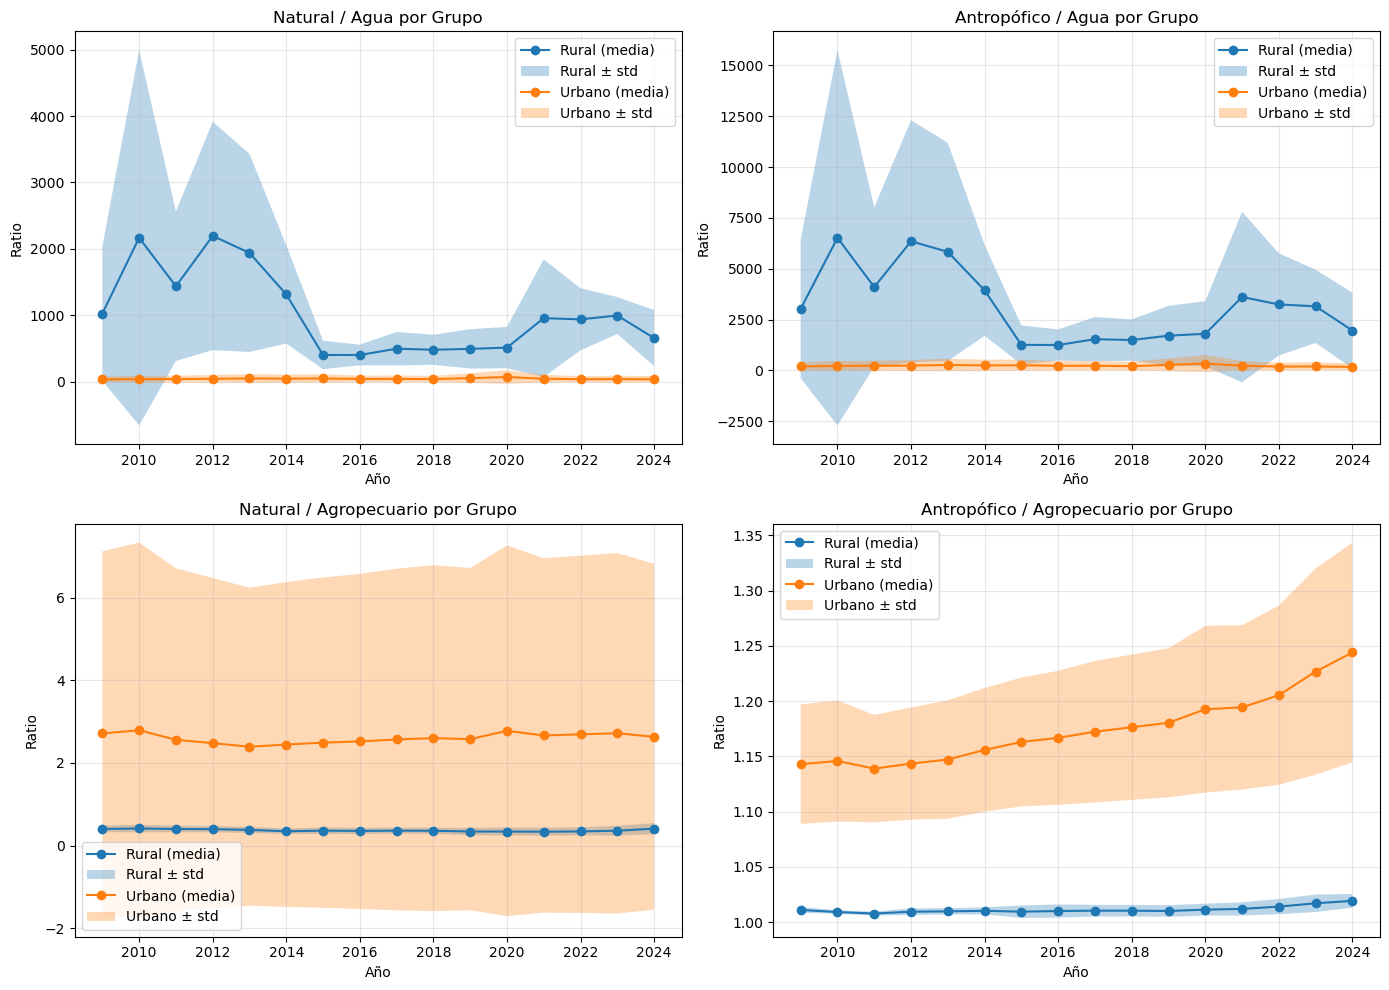

In [17]:

def plot_group_comparison(df_results, ratios=['R1_natural_water', 'R2_anthropic_water', 'R3_natural_agro', 'R4_anthropic_agro']):
    fig, axes = plt.subplots(2, 2, figsize=(14,10))
    axes = axes.flatten()
    ratio_names = {
        'R1_natural_water': 'Natural / Agua',
        'R2_anthropic_water': 'Antropófico / Agua',
        'R3_natural_agro': 'Natural / Agropecuario',
        'R4_anthropic_agro': 'Antropófico / Agropecuario'
    }
    for idx, ratio in enumerate(ratios):
        ax = axes[idx]
        for grupo in ['Rural', 'Urbano']:
            df_group = df_results[df_results['grupo'] == grupo]
            # Compute mean and std per year
            stats = df_group.groupby('year')[ratio].agg(['mean', 'std']).reset_index()
            ax.plot(stats['year'], stats['mean'], marker='o', label=f'{grupo} (media)')
            ax.fill_between(stats['year'], 
                            stats['mean'] - stats['std'], 
                            stats['mean'] + stats['std'], 
                            alpha=0.3, label=f'{grupo} ± std')
        ax.set_title(f'{ratio_names.get(ratio, ratio)} por Grupo')
        ax.set_xlabel('Año')
        ax.set_ylabel('Ratio')
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
plot_group_comparison(df_results)


In [18]:

# Compute net change from 2009 to 2024 for each municipality and category
change_data = []
for mun in all_municipios:
    df_mun = df_results[df_results['municipio'] == mun]
    if df_mun.empty:
        continue
    # Get values for 2009 and 2024
    val_2009 = df_mun[df_mun['year'] == 2009]
    val_2024 = df_mun[df_mun['year'] == 2024]
    if val_2009.empty or val_2024.empty:
        print(f"Warning: missing data for {mun} in 2009 or 2024")
        continue
    # Areas (not proportions)
    # We need to recompute areas or use stored columns; we have area columns in df_results? We have area columns.
    # Let's compute using the original df_filtered for accuracy
    df_mun_orig = df_filtered[df_filtered['municipio'] == mun]
    # Compute total area, natural, anthropic, water, agro for 2009 and 2024
    def get_area(df_sub, year, col):
        cols = year#[str(year)]
        if col == 'total':
            return df_sub[cols].sum().sum()
        elif col == 'natural':
            return df_sub.loc[df_sub['class_level_0'] == 'Natural', cols].sum()
        elif col == 'anthropic':
            return df_sub.loc[df_sub['class_level_0'] == 'Antrópico', cols].sum()
        elif col == 'water':
            return df_sub.loc[df_sub['class_level_1'] == '5. Cuerpo de agua', cols].sum()
        elif col == 'agro':
            return df_sub.loc[df_sub['class_level_1'] == '3. Área  agropecuaria', cols].sum()
        else:
            return np.nan
    areas_2009 = {k: get_area(df_mun_orig, 2009, k) for k in ['total', 'natural', 'anthropic', 'water', 'agro']}
    areas_2024 = {k: get_area(df_mun_orig, 2024, k) for k in ['total', 'natural', 'anthropic', 'water', 'agro']}
    change = {}
    for k in ['total', 'natural', 'anthropic', 'water', 'agro']:
        if not np.isnan(areas_2009[k]) and areas_2009[k] != 0:
            change[f'{k}_change_ha'] = areas_2024[k] - areas_2009[k]
            change[f'{k}_change_pct'] = (areas_2024[k] - areas_2009[k]) / areas_2009[k] * 100
        else:
            change[f'{k}_change_ha'] = np.nan
            change[f'{k}_change_pct'] = np.nan
    change['municipio'] = mun
    change_data.append(change)
df_change = pd.DataFrame(change_data)
print('Cambio neto 2009-2024:')
display(df_change[['municipio', 'natural_change_ha', 'natural_change_pct', 
                   'anthropic_change_ha', 'anthropic_change_pct',
                   'water_change_ha', 'water_change_pct',
                   'agro_change_ha', 'agro_change_pct']])


Cambio neto 2009-2024:


,municipio,natural_change_ha,natural_change_pct,anthropic_change_ha,anthropic_change_pct,water_change_ha,water_change_pct,agro_change_ha,agro_change_pct
0,Cachipay,-183.640863,-10.743378,183.640863,4.990370,-3.653239,-40.594834,132.229816,3.641167
1,Anolaima,-295.523884,-10.268167,295.523884,3.208981,0.979995,73.327844,260.686419,2.863999
2,Zipacón,309.782243,19.638950,-309.782243,-8.107415,1.158312,54.167082,-334.729651,-8.833445
3,Facatativá,653.748920,24.802023,-653.748920,-4.967243,4.632335,15.027464,-1131.812396,-9.334479
4,Mosquera,-1380.561373,-1.818405,1380.561373,12.337636,15.438898,0.112027,255.311315,2.625626
5,Madrid,-36.082479,-3.254034,36.082479,0.328782,0.445155,0.667064,-951.551377,-10.341311


In [19]:

# Example: dentro de Natural, proporción de bosque (1. Formacion Boscosa) vs otras
# We'll compute for each municipality and year the proportion of forest within natural
def subclass_proportion(df_mun, years, level0_class, level1_class=None, level2_class=None):
    """Return proportion of a subclass within a class level."""
    props = {}
    for year in years:
        ycol = year #str(year)
        # Total area for level0_class
        if level0_class:
            total = df_mun.loc[df_mun['class_level_0'] == level0_class, ycol].sum()
        else:
            total = df_mun[ycol].sum()
        # Subclass area
        if level1_class and level2_class:
            sub = df_mun[(df_mun['class_level_1'] == level1_class) & 
                         (df_mun['class_level_2'] == level2_class)][ycol].sum()
        elif level1_class:
            sub = df_mun[df_mun['class_level_1'] == level1_class][ycol].sum()
        elif level2_class:
            # Assuming level2_class is unique enough
            sub = df_mun[df_mun['class_level_2'] == level2_class][ycol].sum()
        else:
            sub = np.nan
        props[year] = sub / total if total not in [0, np.nan] else np.nan
    return props
# Example: proportion of forest (1. Formacion Boscosa) within natural
# We'll compute for one municipality as example
mun_example = 'Cachipay'
df_mun_ex = df_filtered[df_filtered['municipio'] == mun_example]
years_ex = list(range(2009, 2025))
forest_prop = subclass_proportion(df_mun_ex, years_ex, level0_class='Natural', level1_class='1. Formacion Boscosa')
print(f'Proportion of forest within natural for {mun_example}:')
for y, p in forest_prop.items():
    if not np.isnan(p):
        print(f'  {y}: {p:.2%}')


Proportion of forest within natural for Cachipay:
  2009: 99.46%
  2010: 99.80%
  2011: 99.84%
  2012: 99.84%
  2013: 99.78%
  2014: 99.80%
  2015: 99.61%
  2016: 99.68%
  2017: 99.74%
  2018: 99.74%
  2019: 99.70%
  2020: 99.66%
  2021: 99.76%
  2022: 99.88%
  2023: 99.86%
  2024: 99.55%


## 5.1 Visualización Interactiva (Plotly)

Selecciona municipios y tipos de cobertura mediante checkboxes.

In [20]:
type_plot = 'growing'  # 'prop' or 'area' or 'growing'

if type_plot == 'prop':
    col_natural, col_anthropic, col_water, col_agro = 'prop_natural', 'prop_anthropic', 'prop_water', 'prop_agro'
elif type_plot == 'area':
    col_natural, col_anthropic, col_water, col_agro = 'natural_area', 'anthropic_area', 'water_area', 'agro_area'
elif type_plot == 'growing':
    col_natural, col_anthropic, col_water, col_agro = 'growing_natural', 'growing_anthropic', 'growing_water', 'growing_agro'
else:
    raise ValueError("type_plot must be 'prop' or 'area' or 'growing'")

df_plot = df_results.melt(
    id_vars=['municipio', 'year'],
    value_vars=[col_natural, col_anthropic, col_water, col_agro],
    var_name='cobertura',
    value_name='proporcion'
)

municipios = ['Anolaima', 'Cachipay', 'Facatativá', 'Madrid', 'Mosquera', 'Zipacón']
coberturas = [col_natural, col_anthropic, col_water, col_agro]
cobertura_labels = {
    col_natural: 'Natural',
    col_anthropic: 'Antrópico',
    col_water: 'Agua',
    col_agro: 'Agropecuaria'
}

municipio_colors = {
    'Cachipay': '#1f77b4',
    'Anolaima': '#ff7f0e',
    'Zipacón': '#2ca02c',
    'Facatativá': '#d62728',
    'Mosquera': '#9467bd',
    'Madrid': '#8c564b'
}

cobertura_dash = {
    col_natural: 'solid',
    col_anthropic: 'dash',
    col_water: 'dot',
    col_agro: 'dashdot'
}

fig = go.FigureWidget()
for mun in municipios:
    for cob in coberturas:
        df_sub = df_plot[(df_plot['municipio'] == mun) & (df_plot['cobertura'] == cob)]
        fig.add_trace(go.Scatter(
            x=df_sub['year'],
            y=df_sub['proporcion'],
            mode='lines+markers',
            name=f"{mun} - {cobertura_labels[cob]}",
            line=dict(color=municipio_colors[mun], dash=cobertura_dash[cob]),
            marker=dict(color=municipio_colors[mun]),
            visible=True
        ))

mun_checkboxes = widgets.VBox([widgets.Checkbox(value=True, description=mun) for mun in municipios])
cob_checkboxes = widgets.VBox([widgets.Checkbox(value=True, description=cobertura_labels[cob]) for cob in coberturas])

def update_figure(change=None):
    for mun_idx, mun in enumerate(municipios):
        show_mun = mun_checkboxes.children[mun_idx].value
        for cob_idx, cob in enumerate(coberturas):
            trace_idx = mun_idx * len(coberturas) + cob_idx
            show_cob = cob_checkboxes.children[cob_idx].value
            fig.data[trace_idx].visible = show_mun and show_cob

for cb in list(mun_checkboxes.children) + list(cob_checkboxes.children):
    cb.observe(update_figure, names='value')

title_type = 'Proporción' if type_plot == 'prop' else 'Área' if type_plot == 'area' else 'Crecimiento'

fig.update_layout(
    title=f'Evolución de {title_type} de Cobertura del Suelo',
    xaxis_title='Año',
    yaxis_title=title_type,
    height=700,
    width=1100,
    legend=dict(title='Municipio - Cobertura')
)

display(widgets.HBox([
    widgets.VBox([widgets.HTML('<b>Municipios</b>'), mun_checkboxes]),
    widgets.VBox([widgets.HTML('<b>Cobertura</b>'), cob_checkboxes])
]))
fig.show()


FigureWidget({
    'data': [{'line': {'color': '#ff7f0e', 'dash': 'solid'},
              'marker': {'color': '#ff7f0e'},
              'mode': 'lines+markers',
              'name': 'Anolaima - Natural',
              'type': 'scatter',
              'uid': 'd4434cbe-2dbe-4a33-94f7-59595b85c907',
              'visible': True,
              'x': {'bdata': '2QfaB9sH3AfdB94H3wfgB+EH4gfjB+QH5QfmB+cH6Ac=', 'dtype': 'i2'},
              'y': {'bdata': ('AAAAAAAAAAAZDvvoDKbqP2eN9oPK/P' ... 'USPZ0ywPWBC/to2TPAPUlTOE2JJMA='),
                    'dtype': 'f8'}},
             {'line': {'color': '#ff7f0e', 'dash': 'dash'},
              'marker': {'color': '#ff7f0e'},
              'mode': 'lines+markers',
              'name': 'Anolaima - Antrópico',
              'type': 'scatter',
              'uid': 'd5da6b18-be33-4429-9bf9-92708bee3713',
              'visible': True,
              'x': {'bdata': '2QfaB9sH3AfdB94H3wfgB+EH4gfjB+QH5QfmB+cH6Ac=', 'dtype': 'i2'},
              'y': {'bdata': 